### 파일 저장 형식 저장

In [ ]:
date = '251211'
token_method = 'okt' # 'kiwi'
ver = 1
memo = 'dupli_rm'

##### 샘플 데이터

In [1]:
import pandas as pd

In [2]:
# df = pd.read_excel('./실습데이터_컬쳐케어.xlsx')
df = pd.read_excel('./요리 전중후_통합_251211_ver3.xlsx')
df

,Title,Date,Contents
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ..."
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...
...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...


# ◆ 1. 데이터 전처리하기
- 1.1. 행 중복 제거
- 1.2. 특수문자 및 숫자 제거

### 1.1. 행 중복 제거

In [3]:
df = df.drop_duplicates()
df

,Title,Date,Contents
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ..."
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...
...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...


### 1.2. 특수문자 및 숫자 제거
    *정규표현식 사용

In [4]:
import re
from tqdm import tqdm

In [5]:
def re_pattern(string):
    pattern = re.compile(r'[^a-zA-Z가-힣\s\.\!\?]') # "알파벳 대소문자, 한글, 공백, 마침표(.), 느낌표(!), 물음표(?)" 이외 제거
    string = re.sub(pattern, ' ', string)
    
    pattern2 = re.compile(r'\s+')
    result = re.sub(pattern2, ' ', string)
    
    return result

In [6]:
df['Contents_pre1'] = df['Contents'].apply(lambda x: re_pattern(x))
df

C:\Users\4253\AppData\Local\Temp\ipykernel_31924\3774141958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Contents_pre1'] = df['Contents'].apply(lambda x: re_pattern(x))


,Title,Date,Contents,Contents_pre1
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...
...,...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....,우트 오늘의 딜에 보쉬 공구놀이가 떴어요 남아들 필수 아이템 아닌가 싶네요. 주방...
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고 신랑이 택배받구 한시간쯤 조립 ...
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...,지난 주에 도혁맘님께서 정리함 소분해주셔서 잘 받았어요 인사를 일주일만에 해서 죄송...
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...


# ◆ 2. 데이터 형태소 분리하기
* 2.1 불용어적용 및 형태소 분리
* 2.2 데이터 프레임에 추가

In [7]:
# !pip install konlpy

In [ ]:
from konlpy.tag import Okt
okt=Okt()

### 2.1. 불용어적용 및 형태소 분리
    *제공되는 한국어 불용어 파일 사용(ko-stopwords.csv)

In [9]:
stopwords_df = pd.read_csv('./ko-stopwords.csv')
stopwords_df

,stopwords
0,가
1,가까스로
2,가령
3,각
4,각각
...,...
600,진짜
601,두
602,게
603,요


In [10]:
stopwords = set(stopwords_df['stopwords'])
stopwords


{'가',
 '가까스로',
 '가령',
 '각',
 '각각',
 '각자',
 '각종',
 '갖고말하자면',
 '같다',
 '같이',
 '개의치않고',
 '거니와',
 '거바',
 '거의',
 '것',
 '것과 같이',
 '것들',
 '게',
 '게다가',
 '게우다',
 '겨우',
 '견지에서',
 '결과에 이르다',
 '결국',
 '결론을 낼 수 있다',
 '겸사겸사',
 '고려하면',
 '고로',
 '곧',
 '공동으로',
 '과',
 '과연',
 '관계가 있다',
 '관계없이',
 '관련이 있다',
 '관하여',
 '관한',
 '관해서는',
 '구',
 '구체적으로',
 '구토하다',
 '그',
 '그들',
 '그때',
 '그래',
 '그래도',
 '그래서',
 '그러나',
 '그러니',
 '그러니까',
 '그러면',
 '그러므로',
 '그러한즉',
 '그런 까닭에',
 '그런데',
 '그런즉',
 '그럼',
 '그럼에도 불구하고',
 '그렇게 함으로써',
 '그렇지',
 '그렇지 않다면',
 '그렇지 않으면',
 '그렇지만',
 '그렇지않으면',
 '그리고',
 '그리하여',
 '그만이다',
 '그에 따르는',
 '그위에',
 '그저',
 '그중에서',
 '그치지 않다',
 '근거로',
 '근거하여',
 '기대여',
 '기점으로',
 '기준으로',
 '기타',
 '까닭으로',
 '까악',
 '까지',
 '까지 미치다',
 '까지도',
 '꽈당',
 '끙끙',
 '끼익',
 '나',
 '나머지는',
 '남들',
 '남짓',
 '너',
 '너희',
 '너희들',
 '네',
 '넷',
 '년',
 '논하지 않다',
 '놀라다',
 '누가 알겠는가',
 '누구',
 '다른',
 '다른 방면으로',
 '다만',
 '다섯',
 '다소',
 '다수',
 '다시 말하자면',
 '다시말하면',
 '다음',
 '다음에',
 '다음으로',
 '단지',
 '답다',
 '당신',
 '당장',
 '대로 하다',
 '대하면',
 '대하여',
 '대해 말하자면',
 '대해서',
 

In [11]:
def okt_pos_tagging(string):
    pos_words = okt.pos(string, stem=True, norm=True) # 어근 O, 정규화 O
    result = [word for word, tag in pos_words if (word not in stopwords) and (tag in ['Noun', 'Adjective', 'Verb'])]
    return result

In [12]:
okt_pos_tagging(df['Contents_pre1'][0])

['장보기', '무섭다']

### 2.2 데이터 프레임에 추가

In [13]:
tqdm.pandas() # pandas apply 함수 적용 시 tqdm 함수 사용 가능하도록 설정

In [14]:
df['tokenized'] = df['Contents_pre1'].progress_apply(okt_pos_tagging)
df

100%|██████████| 30709/30709 [21:46<00:00, 23.51it/s] 
C:\Users\4253\AppData\Local\Temp\ipykernel_31924\1296476155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokenized'] = df['Contents_pre1'].progress_apply(okt_pos_tagging)


,Title,Date,Contents,Contents_pre1,tokenized
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,"[장보기, 무섭다]"
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가다, 딸, 기숙, 생활, 글, 올라오다, 보, 고등, 생활, ..."
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋다, 트렌디, 식, 재료..."
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤하다, 이유, 배달, 먹다, 카드, 값, 나오다, 건강, 좋아지다, 일도, 쉬..."
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 달, 간, 그렇다, 마트, 근처, 홈플, 최근, 행사, 상품, 좋다, 괜찮..."
...,...,...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....,우트 오늘의 딜에 보쉬 공구놀이가 떴어요 남아들 필수 아이템 아닌가 싶네요. 주방...,"[우트, 오늘, 딜, 보쉬, 공구, 뜨다, 남아, 필수, 아이템, 아니다, 싶다, ..."
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고 신랑이 택배받구 한시간쯤 조립 ...,"[마침, 결혼기념일, 택배, 받다, 조립, 완성, 못, 신랑, 택배, 받다, 조립,..."
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...,지난 주에 도혁맘님께서 정리함 소분해주셔서 잘 받았어요 인사를 일주일만에 해서 죄송...,"[지난, 주, 도혁맘님, 정리, 함, 분해, 주다, 자다, 받다, 인사, 일주일, ..."
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,"[전, 구입, 주방, 냄새, 빼다, 베란다, 세우다, 두다, 날, 추다, 계속, 베..."


# ◆ 3. 벡터화
* 3.1 doc2vec 준비(문서의 순서 매기기)
* 3.2 doc2vec 학습시키기
* 3.3 벡터 값 데이터 프레임에 추가

In [15]:
import gensim #자연어 처리 및 토픽 모델링을 위한 라이브러리
from gensim.models.doc2vec import TaggedDocument
from gensim.models import Doc2Vec

### 3.1 doc2vec 준비
    - word2vec은 단어 하나를 하나의 vector화
    - doc2vec은 문서 하나를 하나의 vector화

In [16]:
tagged_corpus_list = []
for n, i in enumerate(df['tokenized']):
    tag = f"document{n}"
    tagged_corpus_list.append(TaggedDocument(tags=[tag], words= i))

In [17]:
tagged_corpus_list[0]

TaggedDocument(words=['장보기', '무섭다'], tags=['document0'])

### 3.2 doc2vec 학습시키기
    <model 하이퍼파라미터 값>
    # vector_size : 생성할 문서 벡터의 크기
    # alpha: 모델 학습시 초기 학습률 0.025는 일반적으로 사용됨
    # min_alpha: 학습 과정에서 alpha 값을 이 값으로 줄여나가게 됩니다
    # window : 문맥 윈도우 크기, 주변 몇개의 단어의 문맥을 고려하여 학습하는가

In [18]:
model_doc2vec = Doc2Vec(vector_size = 300, # hyper-p
                        alpha = 0.025, # hyper-p
                        min_alpha = 0.01, # hyper-p
                        window = 3, # hyper-p
                        min_count = 1, # 최소 등장 횟수 # hyper-p
                        dm = 1) # hyper-p

In [19]:
# 단어사전 생성
model_doc2vec.build_vocab(tagged_corpus_list)

In [20]:
# 학습
model_doc2vec.train(tagged_corpus_list,
                    total_examples = model_doc2vec.corpus_count,
                    epochs = 100) # hyper-p

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

In [21]:
# 임베딩벡터 출력
model_doc2vec.dv["document0"]

array([-0.01441861,  0.13257141,  0.04488163,  0.10853682,  0.38614076,
       -0.12478284, -0.10032169,  0.14744161,  0.15188387, -0.08576502,
       -0.06547734, -0.11752837, -0.08725182,  0.1424595 , -0.02233705,
       -0.13941278,  0.28089848, -0.00945445,  0.21575679,  0.04298951,
       -0.0518367 , -0.2063149 ,  0.03801582, -0.31896704,  0.14748418,
       -0.04476443,  0.05173229, -0.20289485, -0.21757524, -0.14153558,
        0.0437837 ,  0.042273  , -0.05279933, -0.19554275, -0.03204438,
        0.22043617,  0.10209722, -0.10466508,  0.24865781,  0.05878776,
       -0.20229949,  0.23506309, -0.12556484, -0.30850157,  0.22820891,
        0.18141021, -0.09008294,  0.00801235,  0.13954876,  0.31024724,
       -0.23974644, -0.1313059 , -0.11750465,  0.14466606, -0.05926443,
        0.22153251,  0.11201268, -0.02288294,  0.0585441 ,  0.01727164,
        0.128642  , -0.04126876,  0.0345621 ,  0.02845426,  0.4011848 ,
        0.07124923,  0.15500438,  0.05121178,  0.11394101, -0.04

### 3.3 벡터 값 데이터 프레임에 추가

In [22]:
vector_list = []
for i in range(len(df)):
    doc2vec = model_doc2vec.dv[f'document{i}']
    vector_list.append(doc2vec)

In [23]:
df['vector'] = vector_list
df

C:\Users\4253\AppData\Local\Temp\ipykernel_31924\2558800673.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['vector'] = vector_list


,Title,Date,Contents,Contents_pre1,tokenized,vector
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,"[장보기, 무섭다]","[-0.014418607, 0.13257141, 0.04488163, 0.10853..."
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가다, 딸, 기숙, 생활, 글, 올라오다, 보, 고등, 생활, ...","[0.072440095, -0.36439636, -1.6701, 0.6776513,..."
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋다, 트렌디, 식, 재료...","[0.85231614, -0.6178168, 0.7684433, -0.5640121..."
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤하다, 이유, 배달, 먹다, 카드, 값, 나오다, 건강, 좋아지다, 일도, 쉬...","[0.17480403, 0.20389459, 1.644801, -0.5040853,..."
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 달, 간, 그렇다, 마트, 근처, 홈플, 최근, 행사, 상품, 좋다, 괜찮...","[0.28627193, -0.9729369, 0.29119128, -0.029910..."
...,...,...,...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....,우트 오늘의 딜에 보쉬 공구놀이가 떴어요 남아들 필수 아이템 아닌가 싶네요. 주방...,"[우트, 오늘, 딜, 보쉬, 공구, 뜨다, 남아, 필수, 아이템, 아니다, 싶다, ...","[1.286539, 2.6443954, -0.67915225, -0.41470894..."
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고 신랑이 택배받구 한시간쯤 조립 ...,"[마침, 결혼기념일, 택배, 받다, 조립, 완성, 못, 신랑, 택배, 받다, 조립,...","[-0.08536358, 0.873178, 0.2004409, -1.2299484,..."
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...,지난 주에 도혁맘님께서 정리함 소분해주셔서 잘 받았어요 인사를 일주일만에 해서 죄송...,"[지난, 주, 도혁맘님, 정리, 함, 분해, 주다, 자다, 받다, 인사, 일주일, ...","[-0.122758515, 0.31497836, -0.94600016, -0.068..."
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,"[전, 구입, 주방, 냄새, 빼다, 베란다, 세우다, 두다, 날, 추다, 계속, 베...","[-0.82766974, 1.1784722, -0.20841627, -0.63484..."


In [ ]:
# pickle 형식으로 저장
import pickle

with open(f'./results/vector_df_{date}_{token_method}_{ver}_{memo}.pkl', 'wb') as f:
    pickle.dump(df, f)

In [ ]:
# pickle load
with open(f'./results/vector_df_{date}_{token_method}_{ver}_{memo}.pkl', 'rb') as f:
    df = pickle.load(f)
    
df

,Title,Date,Contents,Contents_pre1,tokenized,vector
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,"[장보기, 무섭다]","[-0.014418607, 0.13257141, 0.04488163, 0.10853..."
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가다, 딸, 기숙, 생활, 글, 올라오다, 보, 고등, 생활, ...","[0.072440095, -0.36439636, -1.6701, 0.6776513,..."
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋다, 트렌디, 식, 재료...","[0.85231614, -0.6178168, 0.7684433, -0.5640121..."
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤하다, 이유, 배달, 먹다, 카드, 값, 나오다, 건강, 좋아지다, 일도, 쉬...","[0.17480403, 0.20389459, 1.644801, -0.5040853,..."
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 달, 간, 그렇다, 마트, 근처, 홈플, 최근, 행사, 상품, 좋다, 괜찮...","[0.28627193, -0.9729369, 0.29119128, -0.029910..."
...,...,...,...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....,우트 오늘의 딜에 보쉬 공구놀이가 떴어요 남아들 필수 아이템 아닌가 싶네요. 주방...,"[우트, 오늘, 딜, 보쉬, 공구, 뜨다, 남아, 필수, 아이템, 아니다, 싶다, ...","[1.286539, 2.6443954, -0.67915225, -0.41470894..."
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고 신랑이 택배받구 한시간쯤 조립 ...,"[마침, 결혼기념일, 택배, 받다, 조립, 완성, 못, 신랑, 택배, 받다, 조립,...","[-0.08536358, 0.873178, 0.2004409, -1.2299484,..."
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...,지난 주에 도혁맘님께서 정리함 소분해주셔서 잘 받았어요 인사를 일주일만에 해서 죄송...,"[지난, 주, 도혁맘님, 정리, 함, 분해, 주다, 자다, 받다, 인사, 일주일, ...","[-0.122758515, 0.31497836, -0.94600016, -0.068..."
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,"[전, 구입, 주방, 냄새, 빼다, 베란다, 세우다, 두다, 날, 추다, 계속, 베...","[-0.82766974, 1.1784722, -0.20841627, -0.63484..."


# ◆ 4. 병합 계층적 클러스터링
* 4.1 ward 기준으로 덴드로그램 그려보기
* 4.2 실루엣 지수 확인해서 토픽 갯수 정하기
* 4.3 가장 적절한 클러스터링 갯수 df에 삽입

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib import pyplot as plt

### 4.1 ward 기준으로 덴드로그램 그려보기

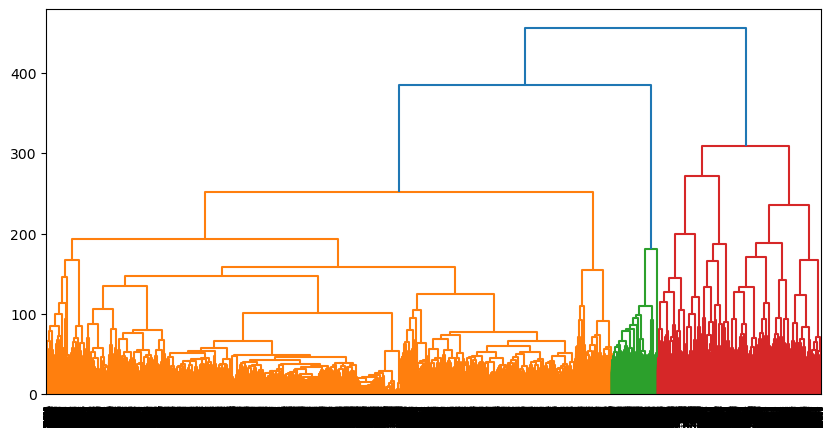

In [27]:
model_linkage = linkage(list(df['vector']), 'ward')

plt.figure(figsize=(10, 5))
dendrogram(model_linkage,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts = False)

plt.show()

### 4.2 실루엣 지수 확인해서 토픽 갯수 정하기

In [28]:
# from sklearn.metrics.cluster import silhouette_score
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering

In [29]:
# 실루엣 지수 구하기
n_cluster = []
clustering_score = []
clustering_score_samples = []

for i in tqdm(range(2, 15)):
    cluster = AgglomerativeClustering(n_clusters = i, linkage='ward')
    cluster_label = cluster.fit_predict(list(df['vector']))
    
    score = silhouette_score(list(df['vector']), cluster_label)
    score_samples = silhouette_samples(list(df['vector']), cluster_label)
    # score = calinski_harabasz_score(list(df['vector']), cluster_label)
    # score = davies_bouldin_score(list(df['vector']), cluster_label)
    
    n_cluster.append(i)
    clustering_score.append(score)
    clustering_score_samples.append(score_samples)

100%|██████████| 13/13 [37:30<00:00, 173.14s/it]


Text(0, 0.5, 'silhouette_score')

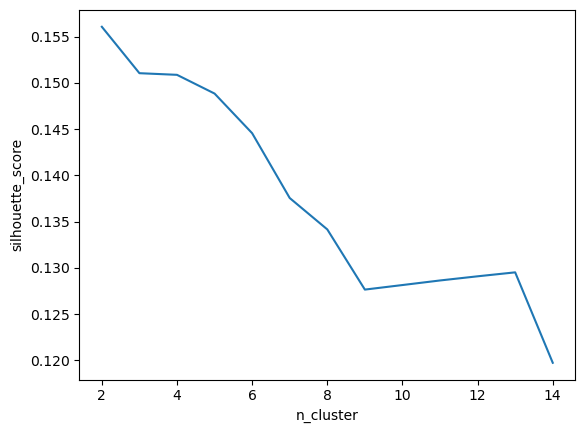

In [30]:
plt.plot(n_cluster, clustering_score)
plt.xlabel("n_cluster")
plt.ylabel("silhouette_score") # 클러스터 내 밀집도와 클러스터 간 분리도 (값이 클수록 좋음)
# plt.ylabel("calinski_harabasz_score") # 분산 기반 분리도 (값이 클수록 좋음)
# plt.ylabel("davies_bouldin_score") # 클러스터 간 거리 대비 내부 분산 (값이 작을수록 좋음)

In [31]:
result = pd.DataFrame([n_cluster, clustering_score]).T
result.columns = ['n_cluster', 'score']
result

,n_cluster,score
0,2.0,0.156054
1,3.0,0.151037
2,4.0,0.150860
3,5.0,0.148835
4,6.0,0.144550
5,7.0,0.137543
6,8.0,0.134150
7,9.0,0.127646
8,10.0,0.128138
9,11.0,0.128632


### 4.3 가장 적절한 클러스터링 갯수 df에 삽입

In [32]:
# 최적 클러스터 수 지정
nc = 3
cluster_model = AgglomerativeClustering(n_clusters = nc, linkage='ward') # hyper-p
cluster_label = cluster_model.fit_predict(list(df['vector']))

In [33]:
df['cluster'] = cluster_label
df

,Title,Date,Contents,Contents_pre1,tokenized,vector,cluster
0,"""장보기가 무서워요""…체감물가 급등에 소비자·소상공인 '한숨'",20251207,[URL]\n\n진짜 장보기 무섭네요\n,URL 진짜 장보기 무섭네요,"[장보기, 무섭다]","[-0.014418607, 0.13257141, 0.04488163, 0.10853...",1
1,사람은 역시 자기가 경험한 만큼 세상을 보네요.,20251206,"고등3학년 올라가는 딸.\n기숙생활하는데,,여기 글 올라온 것들 보니까 고등생활이 ...",고등 학년 올라가는 딸. 기숙생활하는데 여기 글 올라온 것들 보니까 고등생활이 이리...,"[고등, 학년, 올라가다, 딸, 기숙, 생활, 글, 올라오다, 보, 고등, 생활, ...","[0.072440095, -0.36439636, -1.6701, 0.6776513,...",1
2,쿠팡 대신 사용할 수 있는 쇼핑몰 추천(추천 받습니다),20251202,1. 신선제품 새벽배송\n- 마켓컬리: 상품의 질이 좋고 트렌디한 식재료 많음\n[...,. 신선제품 새벽배송 마켓컬리 상품의 질이 좋고 트렌디한 식재료 많음 URL 현재...,"[신선, 제품, 새벽, 배송, 마켓, 컬리, 상품, 질, 좋다, 트렌디, 식, 재료...","[0.85231614, -0.6178168, 0.7684433, -0.5640121...",1
3,장보기(쿠팡 식재료 주문) 봐주세요,20251116,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데\n일도...,피곤하단 이유로 맨날 배달 시켜먹다가 카드값 많이 나오고 건강도 안좋아졌는데 일도 ...,"[피곤하다, 이유, 배달, 먹다, 카드, 값, 나오다, 건강, 좋아지다, 일도, 쉬...","[0.17480403, 0.20389459, 1.644801, -0.5040853,...",1
4,요즘 장보기를 거의 쿠팡과 톡딜에서 해요,20251112,최근 몇 달 간 90%이상이 그럴거같아요\n마트는 근처에 홈플이 있는데 최근에 행사...,최근 몇 달 간 이상이 그럴거같아요 마트는 근처에 홈플이 있는데 최근에 행사 상품들...,"[최근, 달, 간, 그렇다, 마트, 근처, 홈플, 최근, 행사, 상품, 좋다, 괜찮...","[0.28627193, -0.9729369, 0.29119128, -0.029910...",1
...,...,...,...,...,...,...,...
40482,남아 필수 아이템 보쉬 공구놀이 셋트~,20150107,우트 오늘의 딜에 보쉬 공구놀이가 떴어요~\n 남아들 필수 아이템 아닌가 싶네요....,우트 오늘의 딜에 보쉬 공구놀이가 떴어요 남아들 필수 아이템 아닌가 싶네요. 주방...,"[우트, 오늘, 딜, 보쉬, 공구, 뜨다, 남아, 필수, 아이템, 아니다, 싶다, ...","[1.286539, 2.6443954, -0.67915225, -0.41470894...",1
40483,아 너무 기뻐요ㅋㅋ,20140220,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고ㅎ\n\n신랑이 택배받구 한시간쯤...,마침 결혼기념일이라 택배받고 바로 조립 완성 못하고 신랑이 택배받구 한시간쯤 조립 ...,"[마침, 결혼기념일, 택배, 받다, 조립, 완성, 못, 신랑, 택배, 받다, 조립,...","[-0.08536358, 0.873178, 0.2004409, -1.2299484,...",1
40484,코스트코 투명 정리함,20140117,지난 주에 도혁맘님께서 정리함 소분해주셔서\n잘 받았어요~~\n인사를 일주일만에 해...,지난 주에 도혁맘님께서 정리함 소분해주셔서 잘 받았어요 인사를 일주일만에 해서 죄송...,"[지난, 주, 도혁맘님, 정리, 함, 분해, 주다, 자다, 받다, 인사, 일주일, ...","[-0.122758515, 0.31497836, -0.94600016, -0.068...",1
40485,아이가 커가는 재미 ㅎㅎ,20131202,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,얼마전 구입한 주방놀이. 냄새 뺀다고 베란다에 세워두다 날 추운데 계속 베란다에서 ...,"[전, 구입, 주방, 냄새, 빼다, 베란다, 세우다, 두다, 날, 추다, 계속, 베...","[-0.82766974, 1.1784722, -0.20841627, -0.63484...",1


### 클러스터별 실루엣계수 분포 확인

In [34]:
df_si = df.copy()

cluster_model_test = AgglomerativeClustering(n_clusters = nc, linkage='ward')
cluster_label_test = cluster_model_test.fit_predict(list(df['vector']))
score_samples = silhouette_samples(list(df_si['vector']), cluster_label_test)

df_si['cluster'] = cluster_label_test
df_si['silhouette'] = score_samples

df_si[['cluster', 'silhouette']]

,cluster,silhouette
0,1,0.395166
1,1,0.199409
2,1,0.166175
3,1,0.231392
4,1,0.283253
...,...,...
40482,1,0.220027
40483,1,0.239642
40484,1,0.195173
40485,1,0.214766


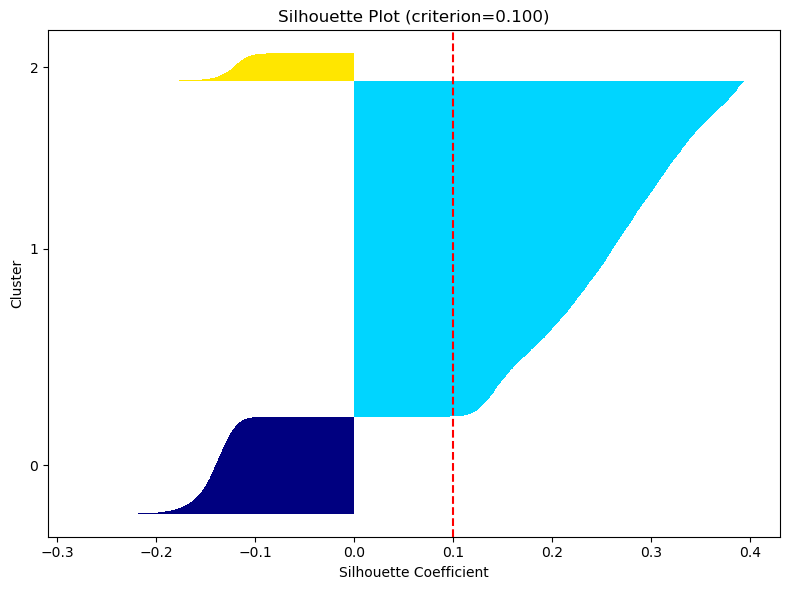

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm

def plot_silhouette_from_df(df_si):
    clusters = df_si['cluster'].unique()
    clusters = sorted(clusters)  # 클러스터 번호 정렬
    n_cluster = len(clusters)

    silhouette_values = df_si['silhouette'].values
    y_lower = 0
    yticks = []

    plt.figure(figsize=(8, 6))

    for c in clusters:
        c_sil = df_si[df_si['cluster'] == c]['silhouette'].sort_values()
        c_sil_values = c_sil.values

        y_upper = y_lower + len(c_sil_values)
        color = cm.jet(float(c) / n_cluster)

        plt.barh(
            range(y_lower, y_upper),
            c_sil_values,
            height=1.0,
            edgecolor='none',
            color=color
        )

        yticks.append((y_lower + y_upper) / 2)
        y_lower = y_upper

    # silhouette_avg = df_si['silhouette'].mean()
    silhouette_avg = 0.1
    plt.axvline(silhouette_avg, color='red', linestyle='--')

    plt.yticks(yticks, clusters)
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")
    plt.title(f"Silhouette Plot (criterion={silhouette_avg:.3f})")

    plt.tight_layout()
    plt.show()

# 사용 예시
plot_silhouette_from_df(df_si)


# ◆ 5. 해석하기:TF-IDF
* 문서 내에서 어떤 단어가 얼마나 중요한지를 평가하는 데 사용되는 방법
* 5.1 TF-IDF 계산
* 5.2 데이터프레임으로 만들고 정렬하기

### 5.1 TF-idf 계산
* 각 클러스터 마다 tfidf가 높은 워드들 찾기
* 각 클러스터들을 하나의 문서로 가정하여 tf-idf 값 추출

In [36]:
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
df['cluster'].unique()

array([1, 0, 2])

In [38]:
all_document = []
for i in df['cluster'].unique():
    print(i)
    pos_tagging = df[df['cluster'] == i]['tokenized']
    
    document = ''
    for pos in pos_tagging:
        doc = " ".join(pos) + " "
        document += doc
        
    all_document.append(document)

1
0
2


In [39]:
len(all_document[0])

6781777

In [40]:
# TF-IDF 벡터라이저 선언
vectorizer = TfidfVectorizer()
# TF-IDF 매트릭스 핏
tfidf_matrix = vectorizer.fit_transform(all_document)

In [41]:
# 키워드 도출
feature_name = vectorizer.get_feature_names_out()
feature_name

array(['가가', '가가호호', '가감', ..., '힙트', '힙합', '힝구'],
      shape=(52493,), dtype=object)

In [42]:
# TF-IDF 값
tfidf_value = tfidf_matrix.toarray()

### 5.2 데이터프레임으로 만들고 정렬하기

In [43]:
# 데이터프레임으로 만들고 정렬하기
tfidf_df = pd.DataFrame(tfidf_value, columns=feature_name)
tfidf_df

,가가,가가호호,가감,가겅비,가게,가겠쥬,가격,가격파괴,가격표,가경,...,힘펠,힘펠꺼네,힙니,힙시트,힙쓰,힙어덕션,힙업,힙트,힙합,힝구
0,0.000973,0.000052,0.000497,0.000026,0.009773,0.000026,0.038708,0.000000,0.000278,0.000020,...,0.000000,0.000026,0.000000,0.000040,0.000052,0.000026,0.000000,0.000000,0.000157,0.000020
1,0.000091,0.000000,0.000044,0.000000,0.001547,0.000000,0.031756,0.000000,0.000011,0.000689,...,0.000019,0.000000,0.000019,0.000029,0.000000,0.000000,0.000019,0.000019,0.000000,0.000015
2,0.000163,0.000000,0.000000,0.000000,0.020070,0.000000,0.035285,0.000055,0.000293,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [44]:
# 인덱스 부여 (cluster 번호)
tfidf_df.index = df['cluster'].unique()
tfidf_df

,가가,가가호호,가감,가겅비,가게,가겠쥬,가격,가격파괴,가격표,가경,...,힘펠,힘펠꺼네,힙니,힙시트,힙쓰,힙어덕션,힙업,힙트,힙합,힝구
1,0.000973,0.000052,0.000497,0.000026,0.009773,0.000026,0.038708,0.000000,0.000278,0.000020,...,0.000000,0.000026,0.000000,0.000040,0.000052,0.000026,0.000000,0.000000,0.000157,0.000020
0,0.000091,0.000000,0.000044,0.000000,0.001547,0.000000,0.031756,0.000000,0.000011,0.000689,...,0.000019,0.000000,0.000019,0.000029,0.000000,0.000000,0.000019,0.000019,0.000000,0.000015
2,0.000163,0.000000,0.000000,0.000000,0.020070,0.000000,0.035285,0.000055,0.000293,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [45]:
# 행열 전환
tfidf_df_T = tfidf_df.T
tfidf_df_T

,1,0,2
가가,0.000973,0.000091,0.000163
가가호호,0.000052,0.000000,0.000000
가감,0.000497,0.000044,0.000000
가겅비,0.000026,0.000000,0.000000
가게,0.009773,0.001547,0.020070
...,...,...,...
힙어덕션,0.000026,0.000000,0.000000
힙업,0.000000,0.000019,0.000000
힙트,0.000000,0.000019,0.000000
힙합,0.000157,0.000000,0.000000


In [ ]:
for i in tfidf_df_T.columns:
    # 점수 정렬
    tfidfvalue = tfidf_df_T[i].sort_values(ascending=False) # 내림차순 정렬
    # 데이터프레임으로 다시 변환
    data = {'tfidf_word': tfidfvalue.index, 'tfidf': tfidfvalue.values}
    data_df = pd.DataFrame(data)
    
    data_df.to_csv(f'./results/cluster{i}_tf_idf_{date}_{token_method}_{ver}_{memo}.csv', encoding='utf-8-sig')

In [ ]:
# excel 파일로 저장
df.to_excel(f'./results/Actor_Clustering_n_{nc}_{date}_{token_method}_{ver}_{memo}.xlsx', index=False)

In [ ]:
# pickle 파일로 저장
with open(f'./results/Actor_Clustering_n_{nc}_{date}_{token_method}_{ver}_{memo}.pkl', 'wb') as f:
    pickle.dump(df, f)

# 페르소나 분석

### 클러스터별 상위 tf-idf 단어(토큰) 추출

In [52]:
cluster_num = 2 # 0 ~ nc-1

tfidfvalue = tfidf_df_T[cluster_num].sort_values(ascending=False) # 오름차순 정렬
tfidfvalue = pd.DataFrame(tfidfvalue)
tfidfvalue.head(20)

,2
먹다,0.562702
좋다,0.342815
맛집,0.263089
맛있다,0.221354
보다,0.176783
들다,0.150588
나오다,0.141824
않다,0.140977
고기,0.129671
정말,0.128727
